In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gaussian_kde
import numpy as np

adata_orig_umap = sc.read_h5ad("output/adata_orig_umap.h5ad")
adata_st_whole_umap = sc.read_h5ad("output/adata_st_whole_umap.h5ad")
adata_st_frag_umap = sc.read_h5ad("output/adata_st_frag_umap.h5ad")
adata_ft_whole_umap = sc.read_h5ad("output/adata_ft_whole_umap.h5ad")
adata_ft_frag_umap = sc.read_h5ad("output/adata_ft_frag_umap.h5ad")

In [10]:
# Load annotations
supervised_df = pd.read_excel(
    "data/breast_cancer_xenium_celltype_supervised.xlsx"
)[["Barcode", "Cluster"]].rename(
    columns={"Cluster": "cluster_supervised"}
)

unsupervised_df = pd.read_excel(
    "data/breast_cancer_xenium_celltype_unsupervised.xlsx"
)[["Barcode", "ident"]].rename(
    columns={"ident": "cluster_unsupervised"}
)

for df in (supervised_df, unsupervised_df):
    df["Barcode"] = (
        df["Barcode"]
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )

def add_annotations(adata):
    obs = adata.obs.copy()

    # obs_names → Barcode (string)
    obs["Barcode"] = obs.index.astype(str)

    obs = (
        obs
        .merge(supervised_df, on="Barcode", how="left")
        .merge(unsupervised_df, on="Barcode", how="left")
        .set_index("Barcode")
    )

    adata.obs = obs
    return adata


# Apply to all AnnData objects
adata_orig_umap = add_annotations(adata_orig_umap)
adata_st_whole_umap = add_annotations(adata_st_whole_umap)
adata_ft_whole_umap = add_annotations(adata_ft_whole_umap)

In [11]:
# Whole cell UMAP configurations
whole_configs = [
    (adata_orig_umap, "_leiden", "Whole cell – Standard Xenium"),
    (adata_st_whole_umap, "_leiden", "Whole cell – Stitched"),
    (adata_ft_whole_umap, "_leiden", "Whole cell – Stitched and Fine-tuned"),
]

clusters_of_interest = {
    "Stromal_&_T_Cell_Hybrid": "#7b5aa5",
    "Stromal": "#dd9aa9",
    "CD4+_T_Cells": "#b094BC",
    "CD8+_T_Cells": "#b094BC",
}

other_color = "#c5dce1"
focus_palette = {**clusters_of_interest, "Other": other_color}

In [12]:
for adata, _, _ in whole_configs:
    adata.obs["cluster_focus"] = (
        adata.obs["cluster_supervised"]
        .where(
            adata.obs["cluster_supervised"].isin(clusters_of_interest),
            "Other",
        )
    )


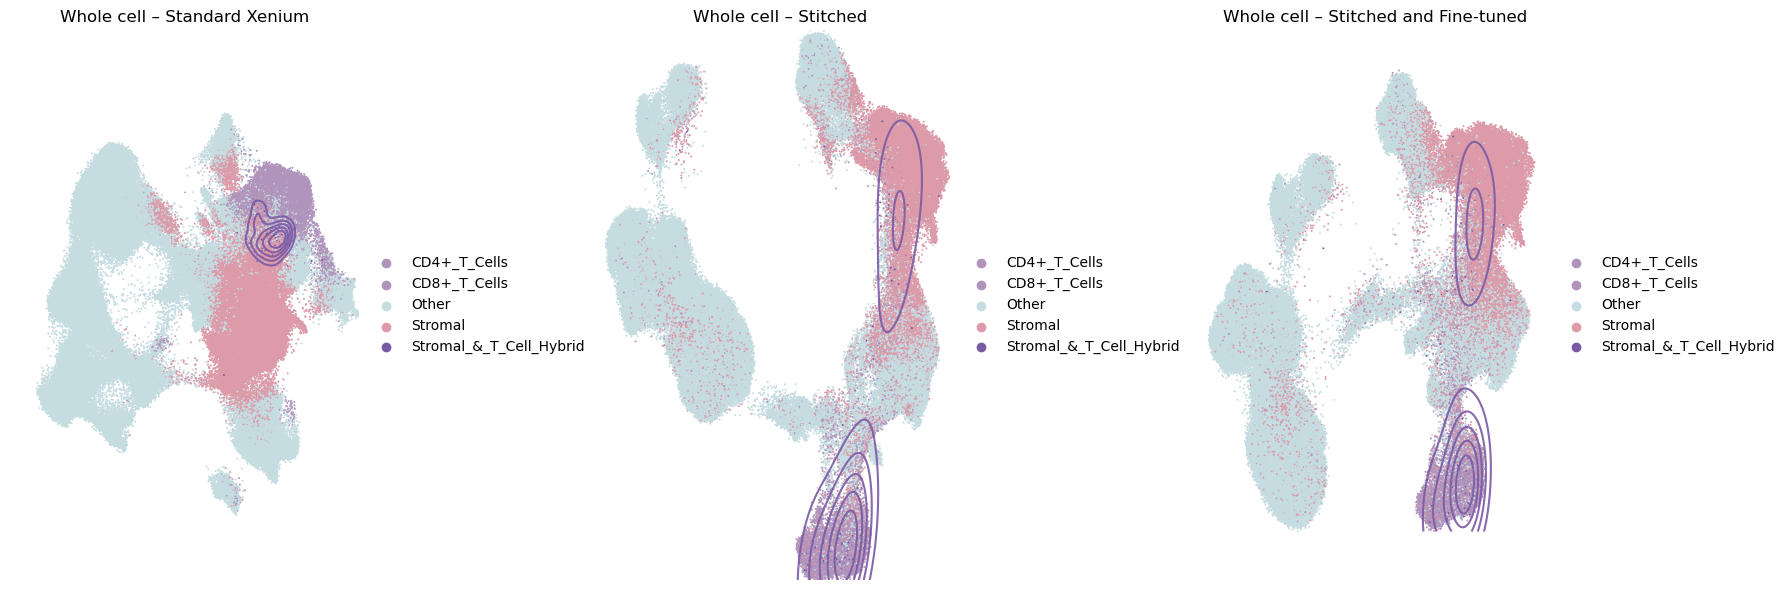

In [19]:
fig, axes = plt.subplots(1, len(whole_configs), figsize=(18, 6), sharex=True, sharey=True)

def clean_umap_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax, (adata, _, title) in zip(axes, whole_configs):

    # Base UMAP
    sc.pl.umap(
        adata,
        color="cluster_focus",
        palette=focus_palette,
        ax=ax,
        show=False,
        title=title,
        size=8,
    )

    # Extract hybrid cluster
    hybrid_mask = (
        adata.obs["cluster_supervised"]
        == "Stromal_&_T_Cell_Hybrid"
    )

    if hybrid_mask.sum() > 10:  # safety check
        umap = adata.obsm["X_umap"]
        hybrid_umap = umap[hybrid_mask.values]

        # KDE
        kde = gaussian_kde(hybrid_umap.T)

        x_min, x_max = umap[:, 0].min(), umap[:, 0].max()
        y_min, y_max = umap[:, 1].min(), umap[:, 1].max()

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 200),
            np.linspace(y_min, y_max, 200),
        )

        zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
        levels = np.linspace(zz.max() * 0.2, zz.max(), 6)  # start from 20% of max

        # Contours
        ax.contour(
            xx,
            yy,
            zz,
            levels=levels,
            colors="#7b5aa5",
            linewidths=1.5,
            alpha=0.9,
        )

    clean_umap_axes(ax)

plt.tight_layout()
plt.savefig(f"plot/breast_cancer_stromal_t_hybrid.png", dpi=600, bbox_inches="tight")
plt.show()


In [21]:
clusters_of_interest = {
    "T_Cell_&_Tumor_Hybrid": "#2c4219",
    "Invasive_Tumor": "#a8b774",
    "DCIS_1": "#a8b774",
    "DCIS_2": "#a8b774",
    "Prolif_Invasive_Tumor": "#a8b774",
    "CD4+_T_Cells": "#deb938",
    "CD8+_T_Cells": "#deb938",
}

other_color = "#f8ec99"
focus_palette = {**clusters_of_interest, "Other": other_color}

In [24]:
for adata, _, _ in whole_configs:
    adata.obs["cluster_focus"] = np.where(
        adata.obs["cluster_supervised"].isin(clusters_of_interest),
        adata.obs["cluster_supervised"],
        "Other"
    )

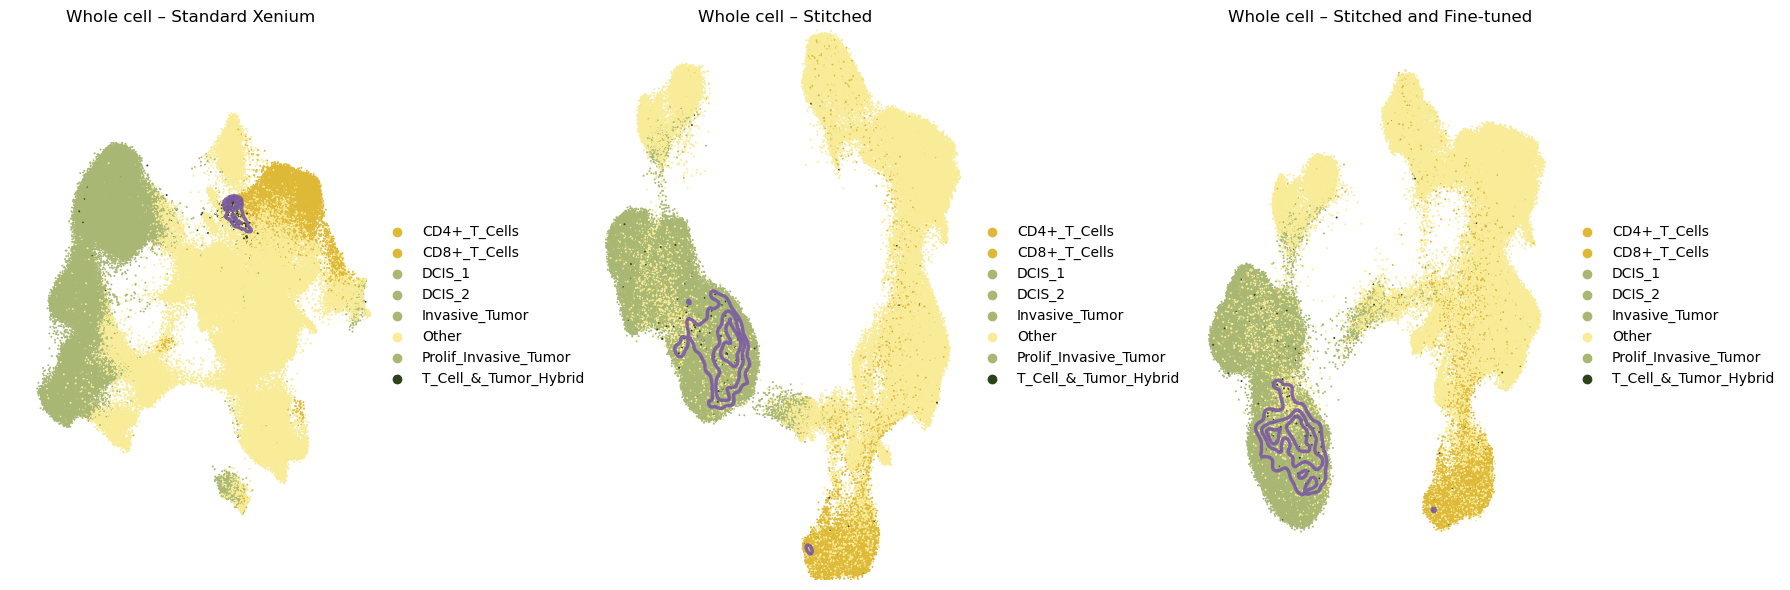

In [38]:
fig, axes = plt.subplots(1, len(whole_configs), figsize=(18, 6), sharex=True, sharey=True)

def clean_umap_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax, (adata, _, title) in zip(axes, whole_configs):

    # Base UMAP
    sc.pl.umap(
        adata,
        color="cluster_focus",
        palette=focus_palette,
        ax=ax,
        show=False,
        title=title,
        size=8,
    )

    # Extract hybrid cluster
    hybrid_mask = (
        adata.obs["cluster_supervised"]
        == "T_Cell_&_Tumor_Hybrid"
    )

    if hybrid_mask.sum() > 10:  # safety check
        umap = adata.obsm["X_umap"]
        hybrid_umap = umap[hybrid_mask.values]

        # KDE
        kde = gaussian_kde(hybrid_umap.T, bw_method=0.07)

        x_min, x_max = umap[:, 0].min(), umap[:, 0].max()
        y_min, y_max = umap[:, 1].min(), umap[:, 1].max()

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 400),
            np.linspace(y_min, y_max, 400),
        )

        zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
        levels = np.linspace(zz.max() * 0.2, zz.max(), 4)  # start from 20% of max

        # Contours
        ax.contour(
            xx,
            yy,
            zz,
            levels=levels,
            colors="#7b5aa5",
            linewidths=2.5,
            alpha=0.9,
        )

    clean_umap_axes(ax)

plt.tight_layout()
plt.savefig(f"plot/breast_cancer_tumor_t_hybrid.png", dpi=600, bbox_inches="tight")
plt.show()


In [53]:
def compute_markers_cluster_supervised(
    adata,
    label_key="cluster_supervised",
    remove_labels=None,  # now accepts a list
    method="wilcoxon"
):
    if remove_labels is None:
        remove_labels = []  # default: remove nothing

    # Filter out rows with NA or any label in remove_labels
    mask = adata.obs[label_key].notna() & (~adata.obs[label_key].isin(remove_labels))
    adata_filt = adata[mask].copy()

    # Ensure categorical
    adata_filt.obs[label_key] = adata_filt.obs[label_key].astype("category")

    # Rank genes
    sc.tl.rank_genes_groups(
        adata_filt,
        groupby=label_key,
        method=method
    )

    return adata_filt


In [54]:
adata_orig_markers = compute_markers_cluster_supervised(adata_orig_umap, remove_labels=["T_Cell_&_Tumor_Hybrid", "Stromal_&_T_Cell_Hybrid", "Unlabeled"])
adata_st_markers   = compute_markers_cluster_supervised(adata_st_whole_umap, remove_labels=["T_Cell_&_Tumor_Hybrid", "Stromal_&_T_Cell_Hybrid", "Unlabeled"])
adata_ft_markers   = compute_markers_cluster_supervised(adata_ft_whole_umap, remove_labels=["T_Cell_&_Tumor_Hybrid", "Stromal_&_T_Cell_Hybrid", "Unlabeled"])

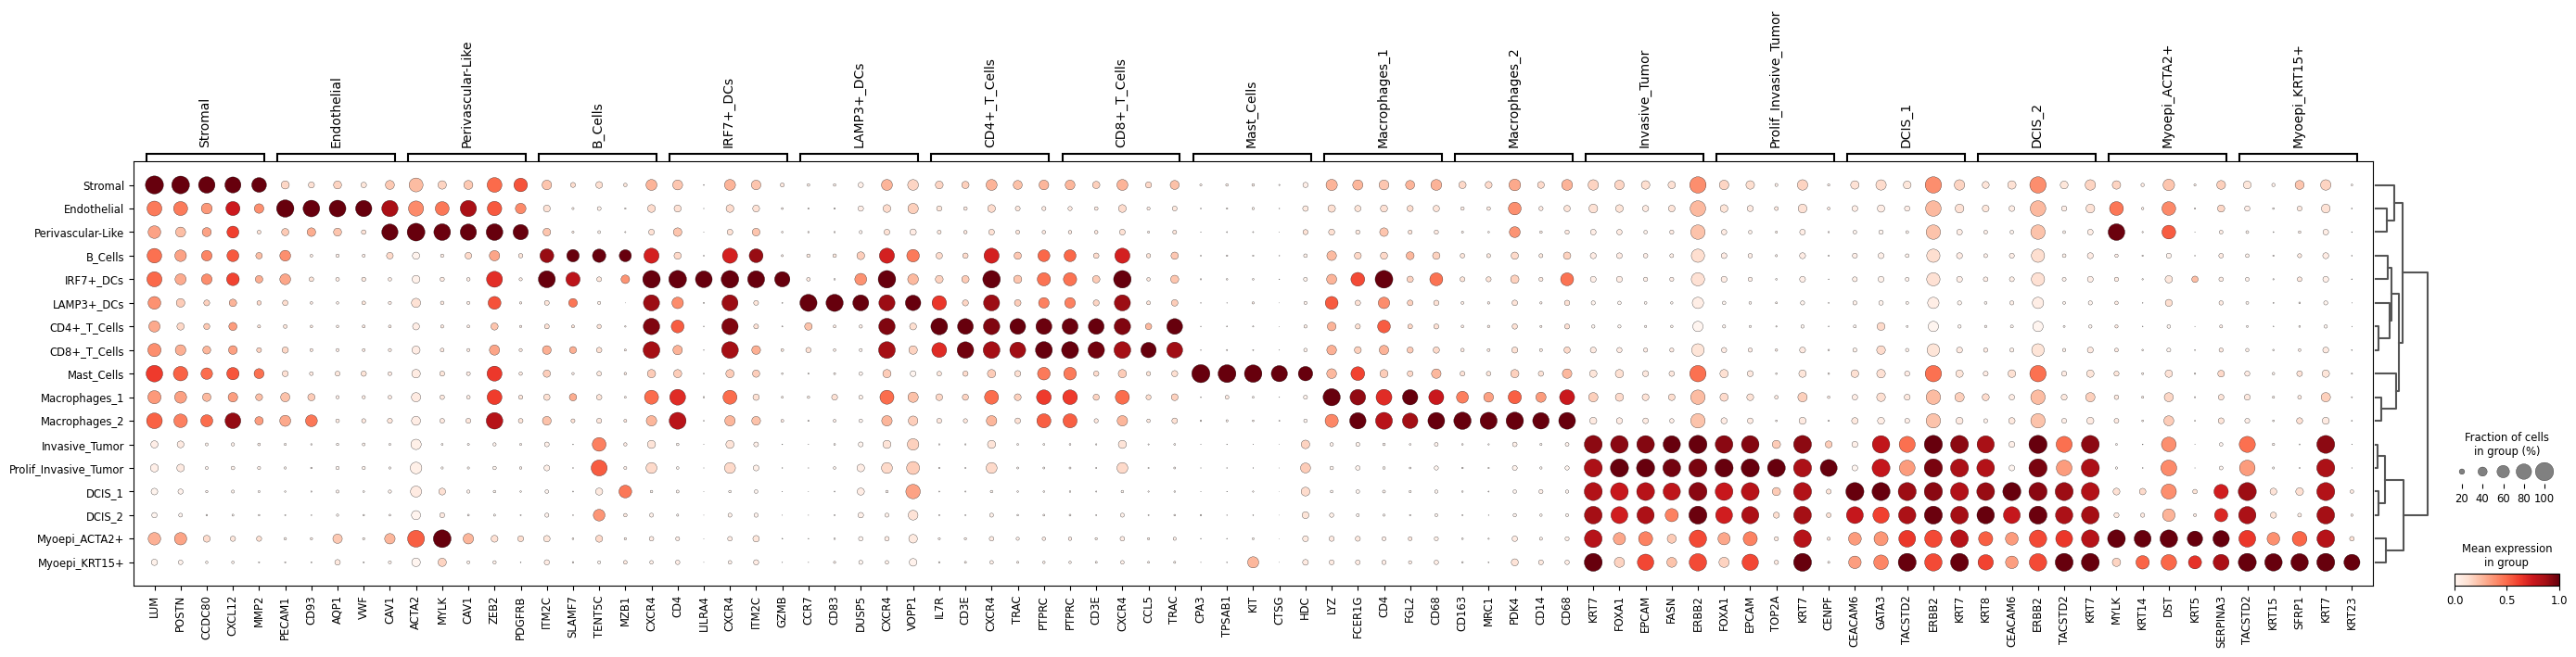

<Figure size 640x480 with 0 Axes>

In [66]:
sc.pl.rank_genes_groups_dotplot(
    adata_orig_markers,
    groupby="cluster_supervised",
    n_genes=5,
    standard_scale="var",
    cmap="Reds"
)
plt.savefig(f"plot/breast_cancer_original_dotplot.png", dpi=300, bbox_inches="tight")

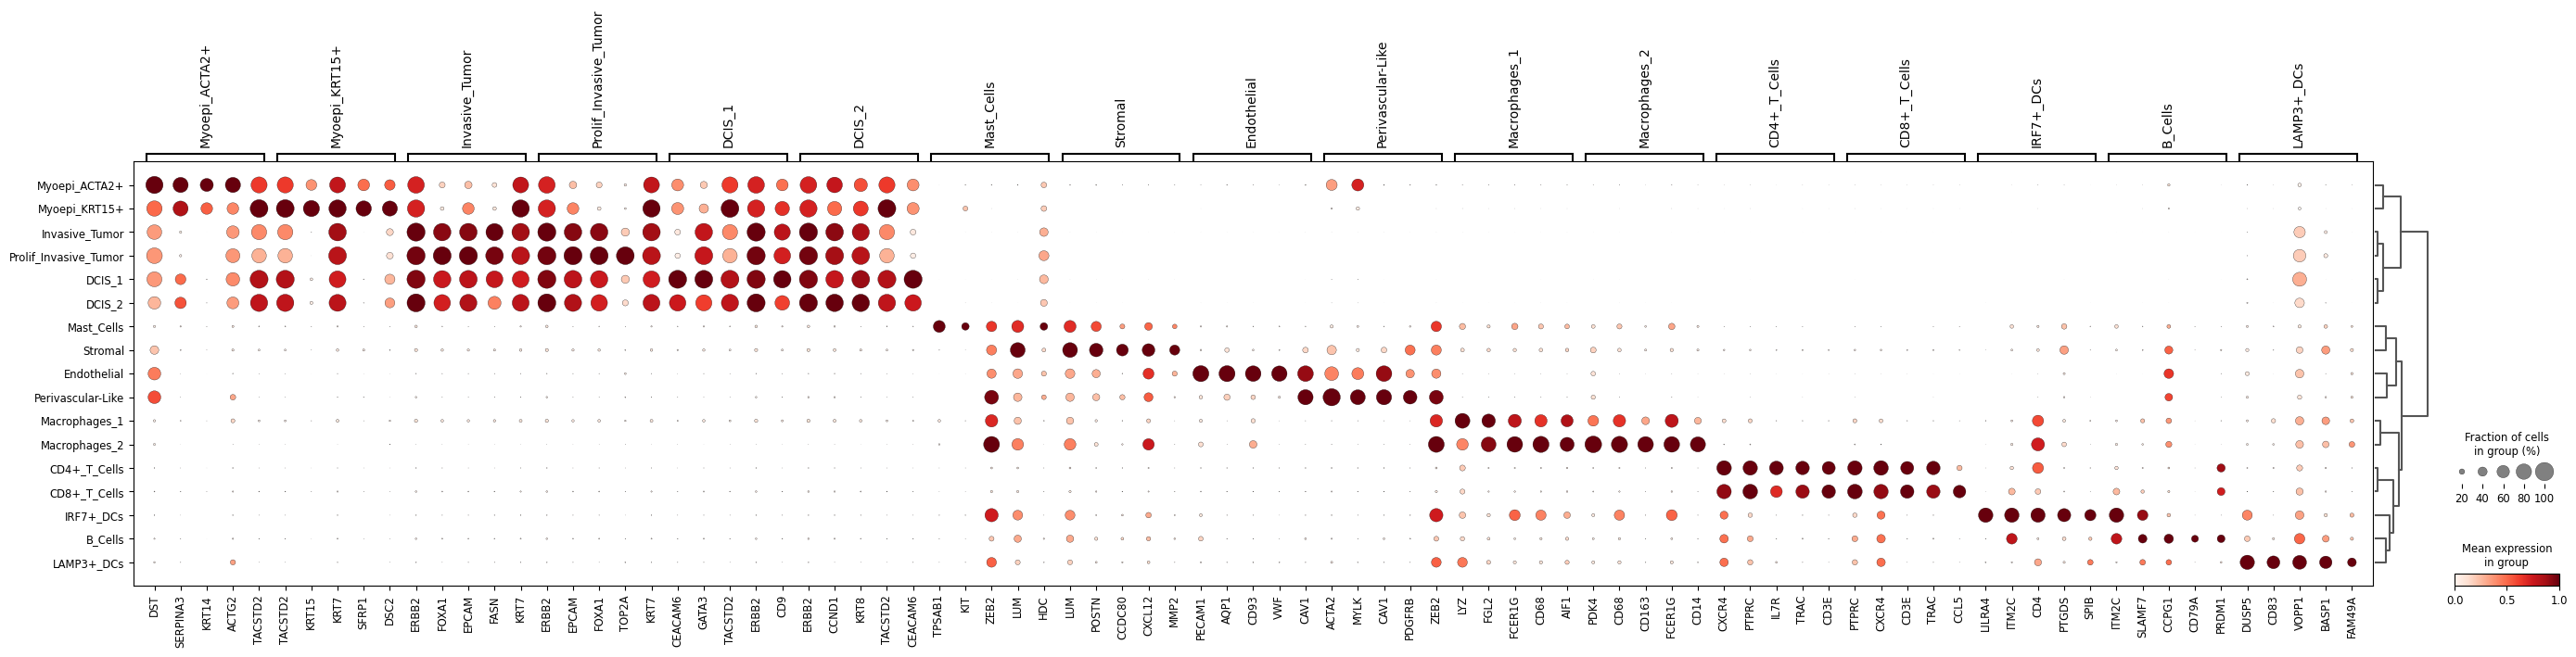

<Figure size 640x480 with 0 Axes>

In [67]:
sc.pl.rank_genes_groups_dotplot(
    adata_ft_markers,
    groupby="cluster_supervised",
    n_genes=5,
    standard_scale="var",
    cmap="Reds"
)
plt.savefig(f"plot/breast_cancer_finetuned_dotplot.png", dpi=300, bbox_inches="tight")

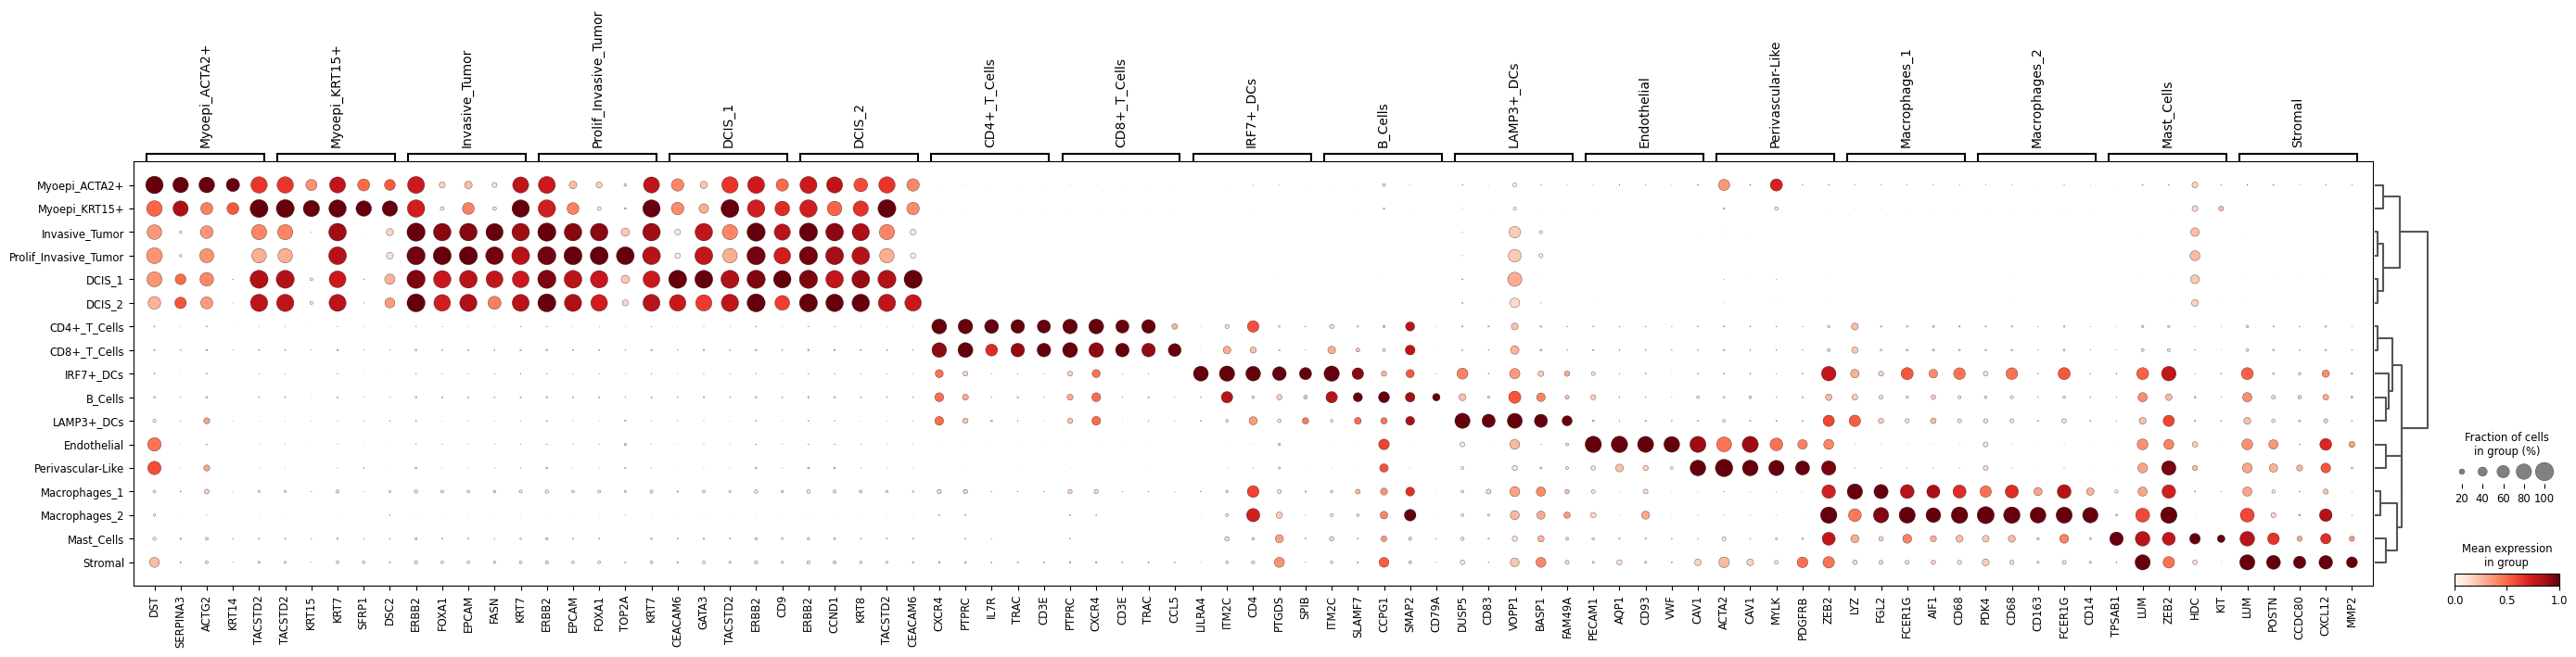

<Figure size 640x480 with 0 Axes>

In [68]:
sc.pl.rank_genes_groups_dotplot(
    adata_st_markers,
    groupby="cluster_supervised",
    n_genes=5,
    standard_scale="var",
    cmap="Reds"
)
plt.savefig(f"plot/breast_cancer_stitched_dotplot.png", dpi=300, bbox_inches="tight")

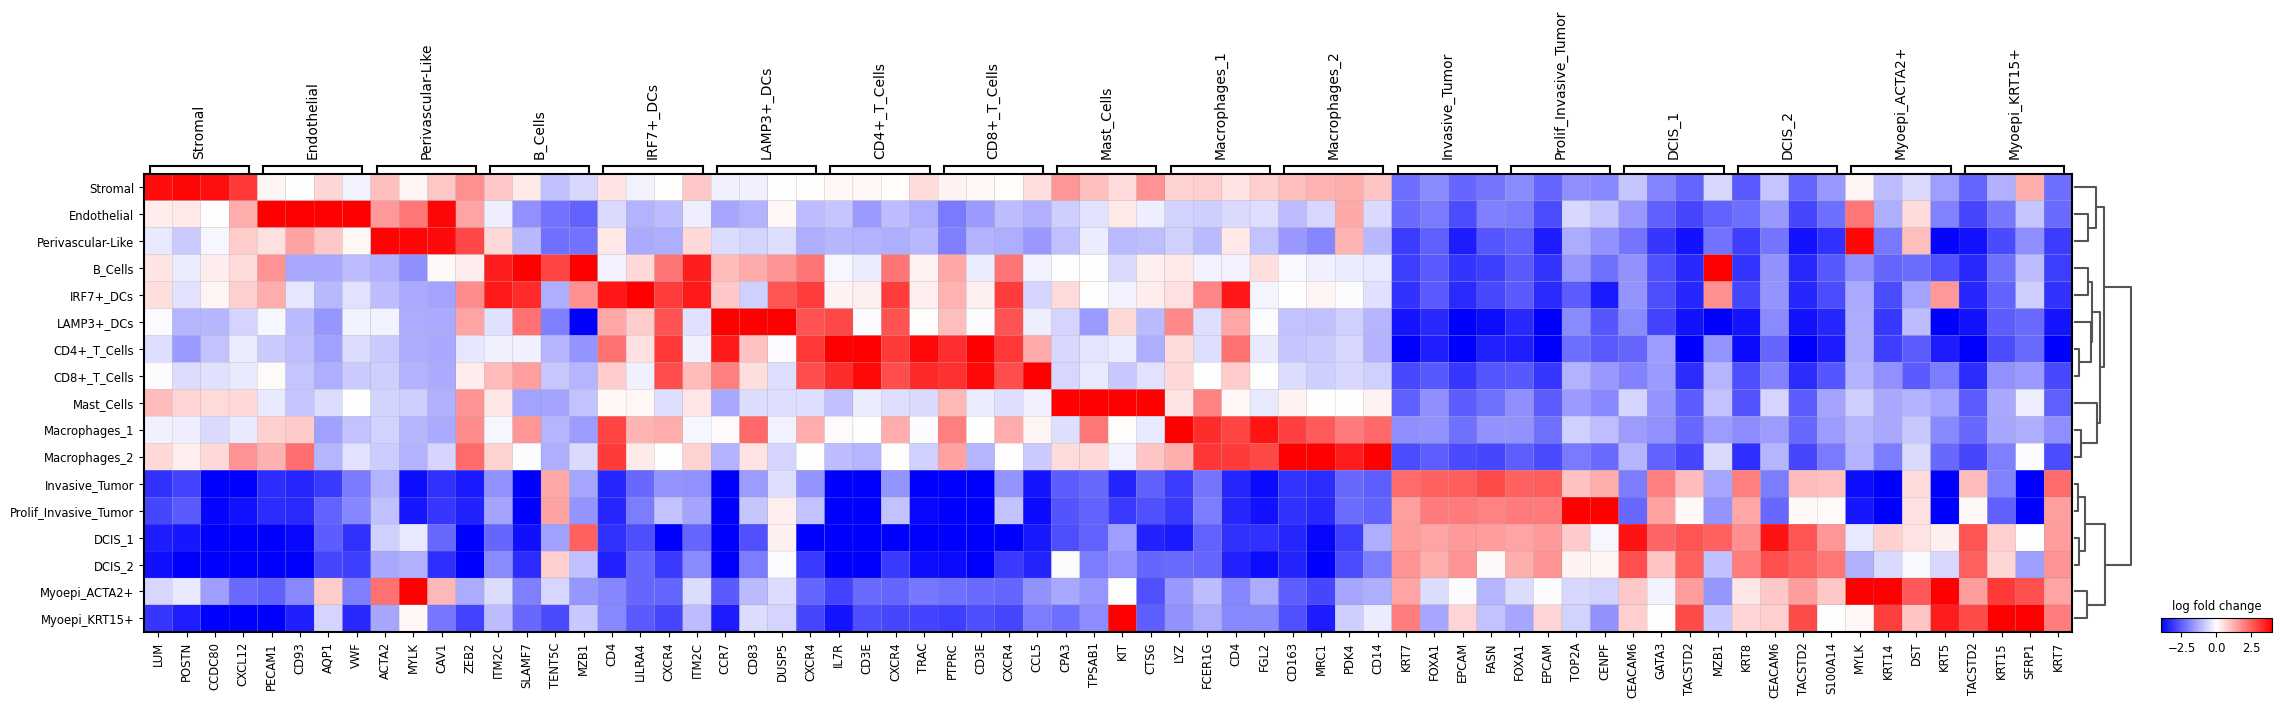

In [65]:
sc.tl.rank_genes_groups(adata_orig_markers, "cluster_supervised")
sc.pl.rank_genes_groups_matrixplot(
    adata_orig_markers,
    n_genes=4,
    values_to_plot="logfoldchanges",
    cmap='bwr',
    vmin=-4,
    vmax=4,
    min_logfoldchange=2,
    colorbar_title='log fold change',
    show=False
)
plt.savefig(f"plot/breast_cancer_original_matrixplot.png", dpi=300, bbox_inches="tight")
plt.show()

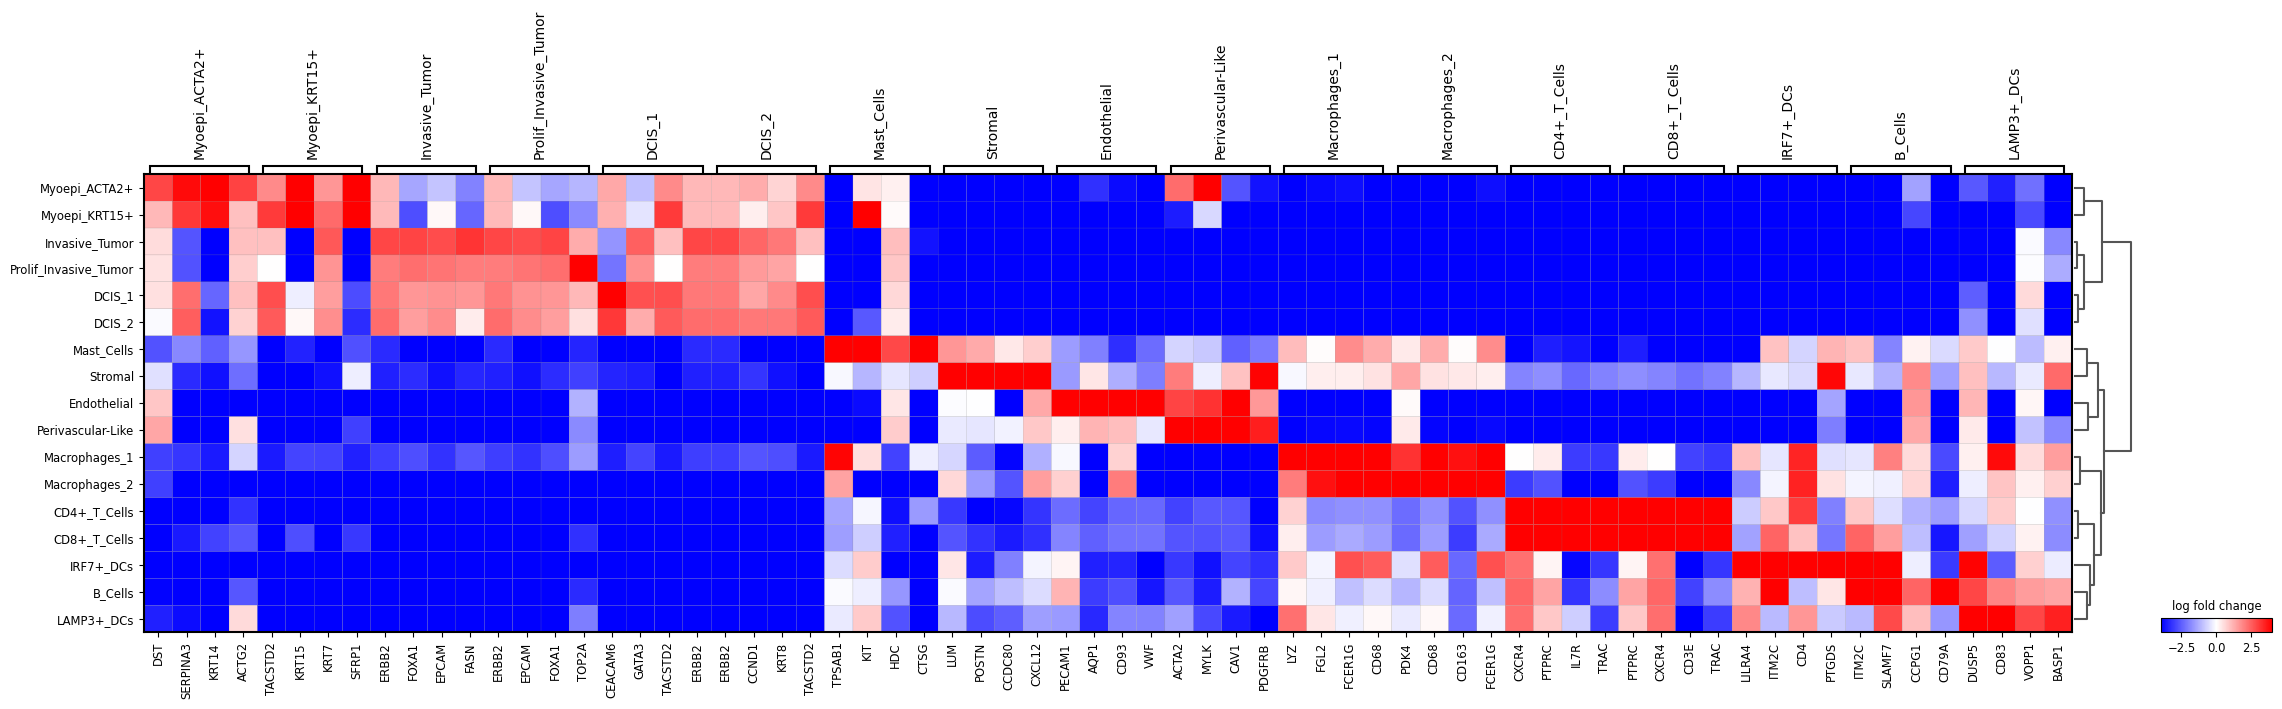

In [69]:
sc.tl.rank_genes_groups(adata_ft_markers, "cluster_supervised")
sc.pl.rank_genes_groups_matrixplot(
    adata_ft_markers,
    n_genes=4,
    values_to_plot="logfoldchanges",
    cmap='bwr',
    vmin=-4,
    vmax=4,
    min_logfoldchange=2,
    colorbar_title='log fold change',
    show=False
)
plt.savefig(f"plot/breast_cancer_finetuned_matrixplot.png", dpi=300, bbox_inches="tight")
plt.show()

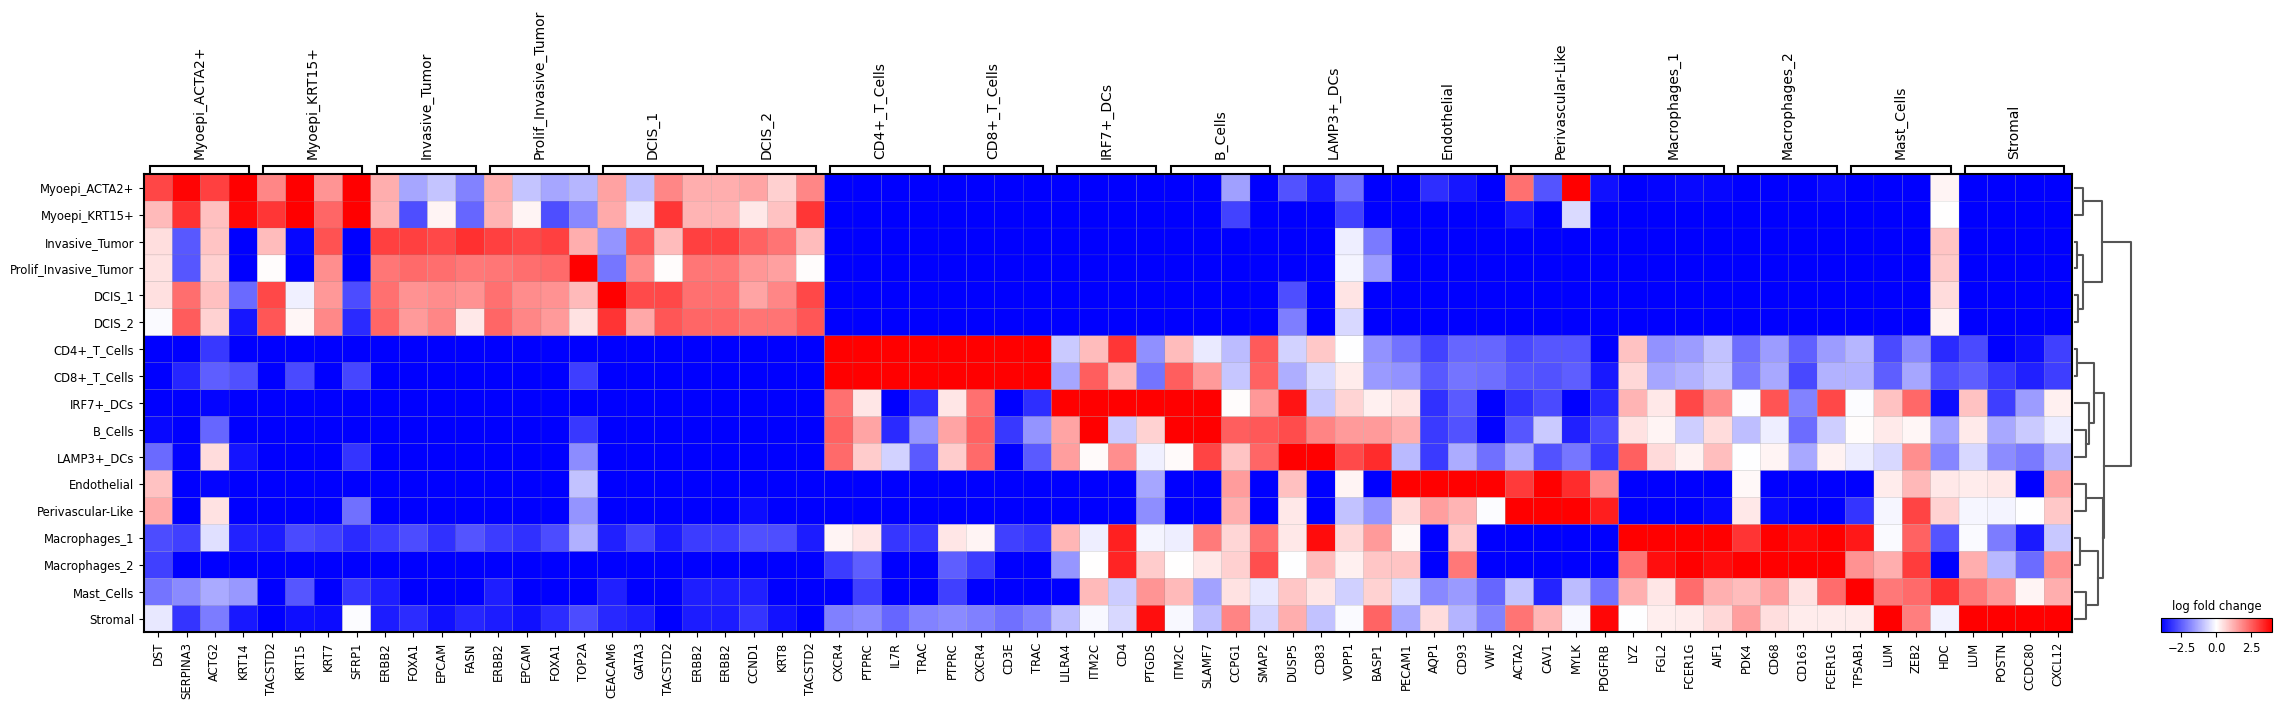

In [70]:
sc.tl.rank_genes_groups(adata_st_markers, "cluster_supervised")
sc.pl.rank_genes_groups_matrixplot(
    adata_st_markers,
    n_genes=4,
    values_to_plot="logfoldchanges",
    cmap='bwr',
    vmin=-4,
    vmax=4,
    min_logfoldchange=2,
    colorbar_title='log fold change',
    show=False
)
plt.savefig(f"plot/breast_cancer_stitched_matrixplot.png", dpi=300, bbox_inches="tight")
plt.show()

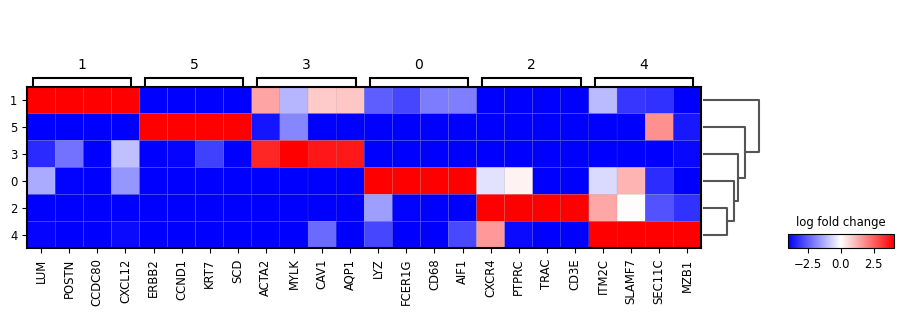

In [62]:
sc.tl.rank_genes_groups(adata_ft_frag_umap, "_leiden")
sc.pl.rank_genes_groups_matrixplot(
    adata_ft_frag_umap,
    n_genes=4,
    values_to_plot="logfoldchanges",
    cmap='bwr',
    vmin=-4,
    vmax=4,
    min_logfoldchange=3,
    colorbar_title='log fold change',
    show=False
)
plt.savefig(f"plot/breast_cancer_partial_pseudocell_matrixplot.png", dpi=300, bbox_inches="tight")
plt.show()